# 01 — Black-Scholes Option Pricing

The Black-Scholes model gives a closed-form price for European options. It assumes the underlying follows **Geometric Brownian Motion** and that continuous delta-hedging is possible — eliminating all risk, which forces the return to equal the risk-free rate.

The resulting PDE has an analytical solution. For a **call option**:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Inputs:**
- $S$ — current stock price
- $K$ — strike price
- $T$ — time to expiry (years)
- $r$ — risk-free rate (annualized)
- $\sigma$ — volatility (annualized)

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from black_scholes import call_price, put_price

## Baseline example
Apple-like parameters: stock at 150, ATM strike, 3 months to expiry.

In [2]:
S     = 150.0   # stock price
K     = 150.0   # strike (at-the-money)
T     = 0.25    # 3 months
r     = 0.05    # 5% risk-free rate
sigma = 0.20    # 20% volatility

c = call_price(S, K, T, r, sigma)
p = put_price(S, K, T, r, sigma)

print(f"Call price : ${c:.4f}")
print(f"Put price  : ${p:.4f}")
print(f"Put-call parity check (C - P = S - Ke^(-rT)): {c - p:.4f} vs {S - K * np.exp(-r * T):.4f}")

Call price : $6.9225
Put price  : $5.0592
Put-call parity check (C - P = S - Ke^(-rT)): 1.8633 vs 1.8633


## Call price vs. stock price $S$
As $S$ rises above the strike, the call moves into the money and its value grows. Below the strike, it approaches zero but retains time value.

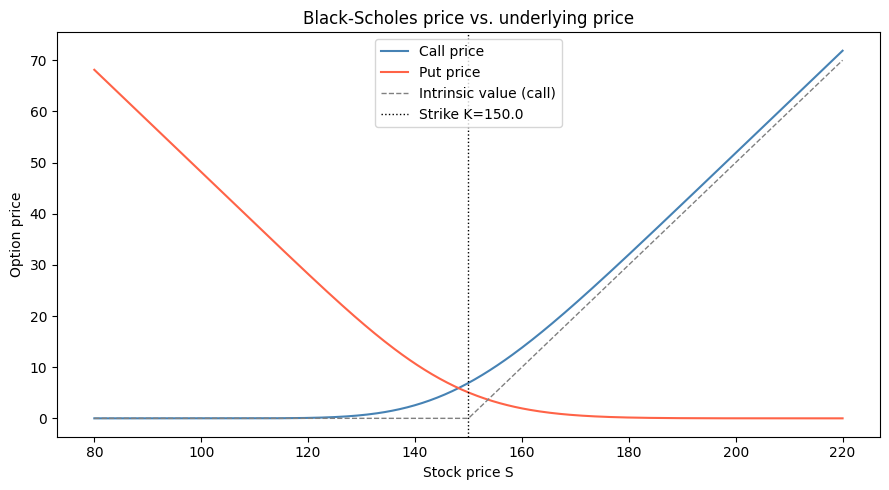

In [3]:
S_range = np.linspace(80, 220, 300)
calls   = [call_price(s, K, T, r, sigma) for s in S_range]
puts    = [put_price(s, K, T, r, sigma)  for s in S_range]
intrinsic_call = np.maximum(S_range - K, 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_range, calls, label='Call price', color='steelblue')
ax.plot(S_range, puts,  label='Put price',  color='tomato')
ax.plot(S_range, intrinsic_call, '--', label='Intrinsic value (call)', color='gray', linewidth=1)
ax.axvline(K, color='black', linestyle=':', linewidth=1, label=f'Strike K={K}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Option price')
ax.set_title('Black-Scholes price vs. underlying price')
ax.legend()
plt.tight_layout()
plt.show()

## Call price vs. volatility $\sigma$
Higher volatility → higher chance of large moves in either direction → option more valuable. This relationship is monotone for vanilla options.

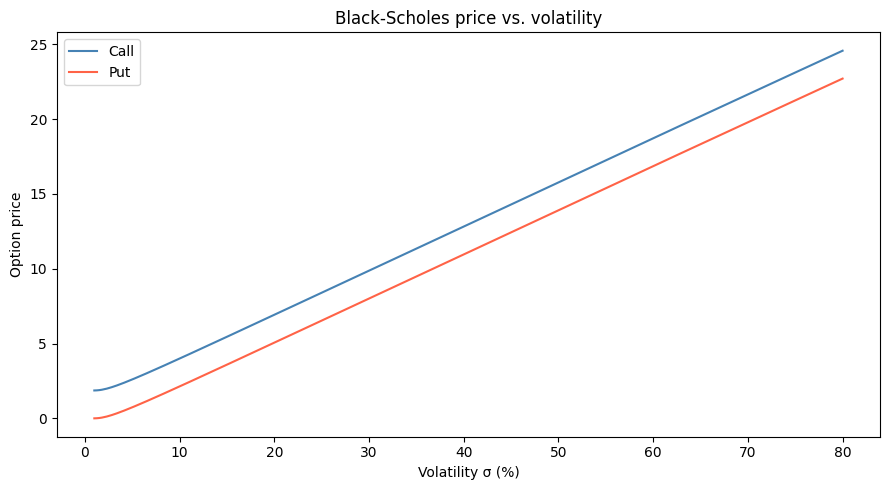

In [4]:
sigma_range = np.linspace(0.01, 0.80, 300)
calls_sigma = [call_price(S, K, T, r, s) for s in sigma_range]
puts_sigma  = [put_price(S, K, T, r, s)  for s in sigma_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sigma_range * 100, calls_sigma, label='Call', color='steelblue')
ax.plot(sigma_range * 100, puts_sigma,  label='Put',  color='tomato')
ax.set_xlabel('Volatility σ (%)')
ax.set_ylabel('Option price')
ax.set_title('Black-Scholes price vs. volatility')
ax.legend()
plt.tight_layout()
plt.show()

## Call price vs. time to expiry $T$
More time → more uncertainty → higher option value. At $T=0$, the option is worth only its intrinsic value.

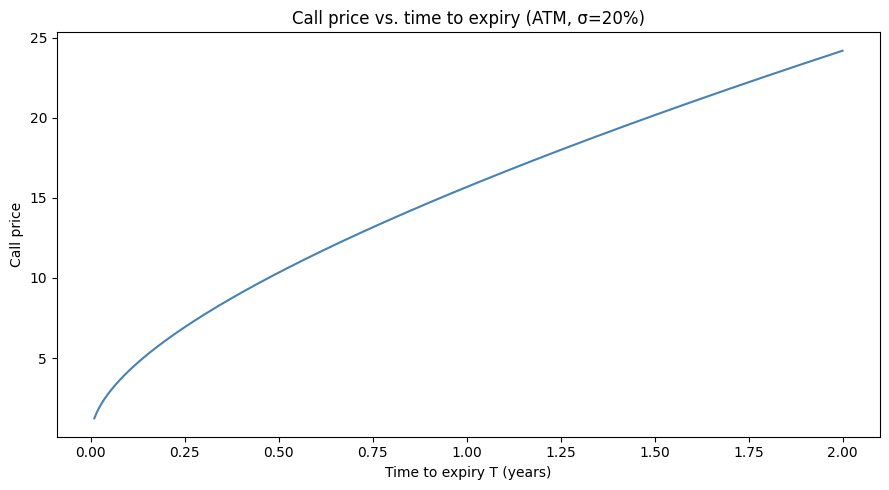

In [5]:
T_range  = np.linspace(0.01, 2.0, 300)  # 1 day to 2 years
calls_T  = [call_price(S, K, t, r, sigma) for t in T_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_range, calls_T, color='steelblue')
ax.set_xlabel('Time to expiry T (years)')
ax.set_ylabel('Call price')
ax.set_title('Call price vs. time to expiry (ATM, σ=20%)')
plt.tight_layout()
plt.show()

## Fetching real market data
We use `yfinance` to pull a real option chain and compare model prices to market prices.
The gap between model and market price is where the interesting questions start.

In [6]:
import yfinance as yf
import pandas as pd

ticker = yf.Ticker('AAPL')
S_real = ticker.history(period='1d')['Close'].iloc[-1]
print(f"AAPL spot price: ${S_real:.2f}")

# pick the nearest expiry with reasonable liquidity
expiry = ticker.options[1]
chain  = ticker.option_chain(expiry)
calls  = chain.calls[['strike', 'lastPrice', 'impliedVolatility', 'volume']].copy()

# time to expiry in years
from datetime import datetime
T_real = (datetime.strptime(expiry, '%Y-%m-%d') - datetime.today()).days / 365
r_real = 0.05

# Black-Scholes price for each strike using market-implied vol
calls['bs_price'] = calls.apply(
    lambda row: call_price(S_real, row['strike'], T_real, r_real, row['impliedVolatility']),
    axis=1
)
calls['diff'] = calls['bs_price'] - calls['lastPrice']

# show strikes closest to ATM
atm_idx = (calls['strike'] - S_real).abs().argsort()
calls.iloc[atm_idx[:8]][['strike', 'lastPrice', 'bs_price', 'diff', 'volume']]

AAPL spot price: $270.23


,strike,lastPrice,bs_price,diff,volume
17,270.0,1.79,1.026013,-0.763987,37777.0
18,272.5,0.84,0.181960,-0.658040,26328.0
16,267.5,3.47,2.920162,-0.549838,11515.0
19,275.0,0.37,0.019121,-0.350879,29778.0
15,265.0,5.54,5.281165,-0.258835,4864.0
14,262.5,8.02,7.785724,-0.234276,968.0
20,280.0,0.07,0.000166,-0.069834,7659.0
13,260.0,9.80,10.271703,0.471703,774.0
